## Python For Machine Learning Fall 2025
---
# The Leap to Deep CNNs

# 1.  Deep versus Shallow Neural Networks

## 1.1 The "Shallow" Neural Networks

In previous sessions, we built a successful "shallow" CNN, probably something like `[CONV -> RELU -> POOL] x 2 -> FC x 3 -> SOFTMAX`. Excluding the input layer because it has no neurons, this network architecture consists of six layers, with the sixth layer being the output layer. Looking back at the "deep learning era" of the past 10 to 15 years, this is considered a relatively shallow network. The first two convolutional layers extract information from the image, and the subsequent fully connected layers map the feature maps to the output.

## 1.2 Go Deeper?

The core hypothesis of deep learning is that **hierarchical features** are key to performance. Much like the human visual cortex, deep networks build complex representations layer by layer.

**Feature Hierarchy (Conceptual)**

* **Layer 1:** Learns simple edges, corners, and color gradients.
* **Layer 5:** Learns to combine edges into textures, patterns, and simple shapes.
* **Layer 10:** Learns "parts" of objects (an eye, a wheel, a handle).
* **Layer 20+:** Learns to combine parts into full, abstract object representations (a face, a car, a dog).

More layers allow for more complex and abstract feature representations.

**The Question:** So, can't we just stack 50 of our `CONV -> RELU` blocks?

**The Answer:** No. If you try, the network's performance actually gets *worse* as you add more layers beyond a certain point. This is known as the **degradation problem**.

# 2. The Unstable Gradients

The reason "just stacking layers" fails is due to **vanishing** and **exploding gradients**.

Recall backpropagation. To update a weight in an early layer (e.g., $W_1$), we use the chain rule. The gradient is a **product of all the gradient terms** from the output layer back to that weight.

$$ \frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial A_n} \times \dots \times \frac{\partial A_3}{\partial Z_2} \times \frac{\partial Z_2}{\partial A_2} \times \frac{\partial A_2}{\partial Z_1} \times \frac{\partial Z_1}{\partial W_1} $$

The problem is this long chain of multiplications.


## 2.1 Vanishing Gradients

What happens if many of these terms (especially the activation function's derivative) are small numbers (e.g., < 0.5)?

Let's look at the derivatives of `sigmoid` and `tanh`, which were common in shallow networks.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set up default plot settings
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 5)

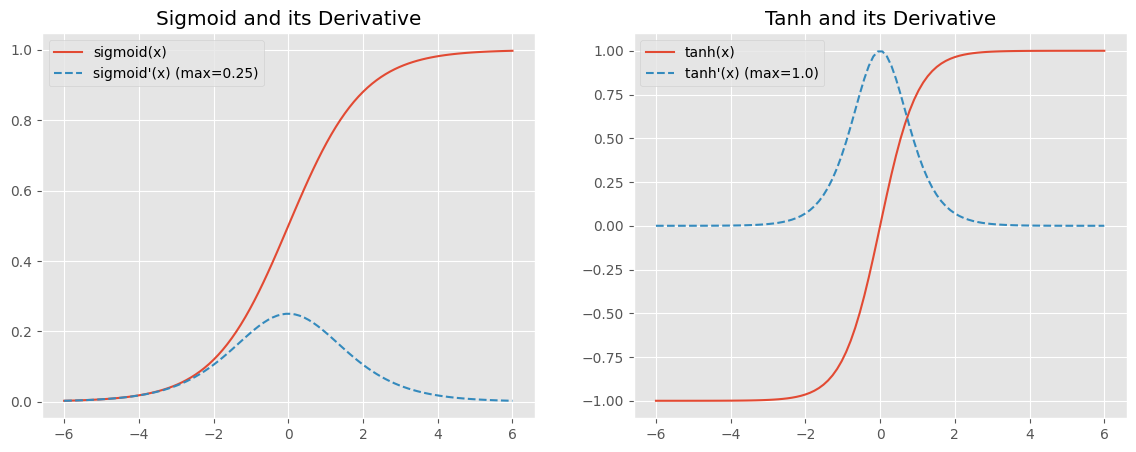

In [ ]:
# Plot 1: Sigmoid/Tanh and their Derivatives
x = torch.linspace(-6, 6, 100)

# Sigmoid
sig = torch.sigmoid(x)
sig_deriv = sig * (1 - sig)

# Tanh
tanh = torch.tanh(x)
tanh_deriv = 1 - tanh**2

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(x, sig, label='sigmoid(x)')
plt.plot(x, sig_deriv, label="sigmoid'(x) (max=0.25)", linestyle='--')
plt.title('Sigmoid and its Derivative')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x, tanh, label='tanh(x)')
plt.plot(x, tanh_deriv, label="tanh'(x) (max=1.0)", linestyle='--')
plt.title('Tanh and its Derivative')
plt.legend()

plt.show()

As you can see, the derivative of `sigmoid` is **at most 0.25**. The derivative of `tanh` is < 1 for most values.

If we multiply these small numbers 50 times (for a 50-layer network):

$$ 0.25 \times 0.25 \times \dots \times 0.25 \text{ (50 times)} \approx 10^{-31} $$

**Consequence:** The gradients for early layers become effectively zero. Their weights are never updated, and the network **cannot learn** its most basic features (like edges).



## 2.2 Exploding Gradients

This is the opposite problem. What if the terms in the chain (especially those involving weights $W$) are large (e.g., > 1.5)?

$$ 1.5 \times 1.5 \times \dots \times 1.5 \text{ (50 times)} \approx 10^8 $$

**Consequence:** The gradient value becomes astronomically large. The weight update (`W_new = W_old - lr * gradient`) is massive, causing the parameters to become unstable, and the loss diverges to `NaN` (Not a Number).

Let's visualize this.

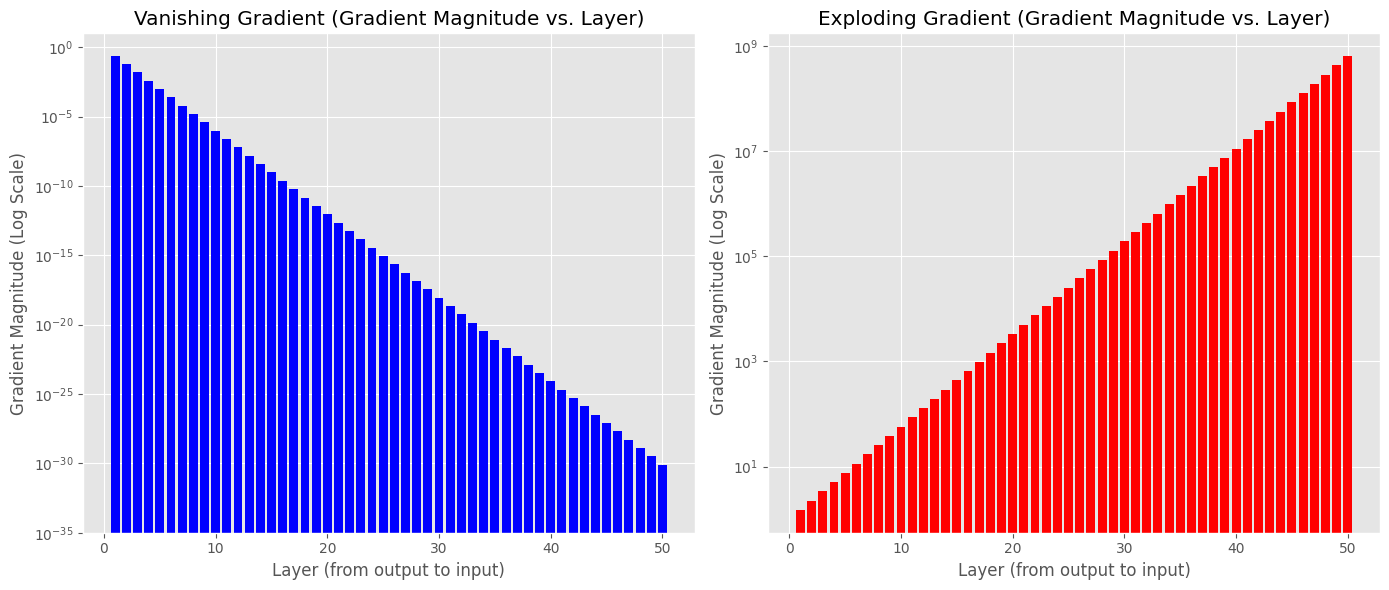

In [ ]:
# Plots 2 & 3: Visualizing Vanishing and Exploding Gradients
num_layers = 50
layer_indices = np.arange(1, num_layers + 1)

# 1. Vanishing Gradient Simulation (multiplying by 0.25)
vanishing_grads = [1.0]
for _ in range(num_layers):
    vanishing_grads.append(vanishing_grads[-1] * 0.25)

# 2. Exploding Gradient Simulation (multiplying by 1.5)
exploding_grads = [1.0]
for _ in range(num_layers):
    exploding_grads.append(exploding_grads[-1] * 1.5)

plt.figure(figsize=(14, 6))

# Plot 2: Vanishing
plt.subplot(1, 2, 1)
plt.bar(layer_indices, vanishing_grads[1:], color='blue')
plt.title('Vanishing Gradient (Gradient Magnitude vs. Layer)')
plt.xlabel('Layer (from output to input)')
plt.ylabel('Gradient Magnitude (Log Scale)')
plt.yscale('log') # Use log scale to even see the first bars
plt.ylim(1e-35, 10)

# Plot 3: Exploding
plt.subplot(1, 2, 2)
plt.bar(layer_indices, exploding_grads[1:], color='red')
plt.title('Exploding Gradient (Gradient Magnitude vs. Layer)')
plt.xlabel('Layer (from output to input)')
plt.ylabel('Gradient Magnitude (Log Scale)')
plt.yscale('log') # Use log scale to see the progression

plt.tight_layout()
plt.show()

To train deep networks, we **must** find a way to keep the gradient signal in a stable, "Goldilocks" zone—not too big, not too small.

# 3. Solutions

Current deep learning methods are quite simple, but discovering them was a very long process. It was unknown how much increasing network depth would help, and experiments were extremely expensive when computing power was limited. The past rises and falls of neural networks reflect this slow experimental process, which spanned decades and was too long for individual researchers. Furthermore, solving deep network learning problems required a combination of methods, not a single technique, which also delayed research.

## 3.1 A Better Activation (ReLU)

We've been using `nn.ReLU`, but *why* is it so critical for deep networks?

Let's look at the function `f(x) = max(0, x)` and its derivative.

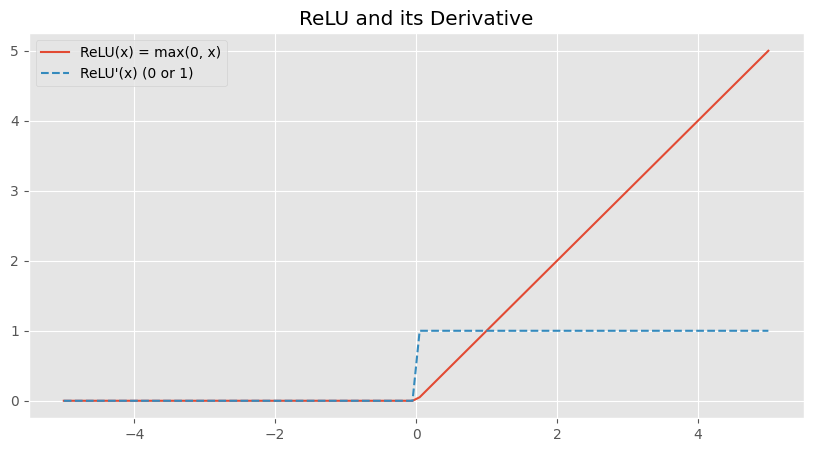

In [ ]:
# Plot 4: ReLU and its Derivative
x = torch.linspace(-5, 5, 100)

# ReLU
relu = torch.relu(x)

# ReLU Derivative
relu_deriv = (x > 0).float()

plt.figure(figsize=(10, 5))
plt.plot(x, relu, label='ReLU(x) = max(0, x)')
plt.plot(x, relu_deriv, label="ReLU'(x) (0 or 1)", linestyle='--')
plt.title('ReLU and its Derivative')
plt.legend()
plt.show()

**ReLU directly combats vanishing gradients**.

The derivative is **1** for all positive inputs (activated neurons) and 0 otherwise.

In the chain rule, we are now multiplying by 1 (or 0).

$$ 1 \times 1 \times 1 \times \dots \times 1 = 1 $$

This **"identity" property of the derivative** is the single biggest reason ReLU is the default for deep networks. It allows the gradient signal to pass **unchanged** through many layers, flowing all the way back to the early layers so they can learn.

* **Other benefits:** It's computationally cheap (no `exp()`) and induces sparsity.
* **Limitation:** ReLU helps, but it doesn't solve everything. A 50-layer "plain" CNN with ReLUs will still struggle. We also need better **architecture**.

## 3.2 Smarter Architectures

ReLU directly helps with the vanishing gradient problem, but it does not provide much help for the exploding gradient problem. During the research process, other designs played a role in addressing this. Two key architectural ideas enable truly deep networks.


### 3.2.1 Normalize What's Flowing (Batch Normalization)

* **Concept:** `nn.BatchNorm2d`.
* **Analogy:** We normalize our input data (mean=0, std=1) before feeding it to the network. What if we did that *inside* the network, between layers?
* **Flow:** The standard flow becomes `CONV -> **BN** -> RELU`.

**How it helps:**
* It forces the activations (the input to ReLU) to have a stable distribution.
* This prevents activations from drifting into saturated (zero-gradient) regions.
* It smooths the loss landscape, which allows for faster training and higher learning rates.
* It also acts as a regularizer.

**Result:** Training is much faster and more stable.



### 3.2.2 Don't Lose the Original Signal (Residual Connections)

* **Concept:** This is the core idea of **ResNet**. It's what unlocked networks with 100+ layers.
* **The Degradation Problem:** Why is a 50-layer net worse than a 20-layer net? The 50-layer net should *at least* be able to learn to be the 20-layer net by making the extra 30 layers just pass the data through (an **identity mapping**). But it struggles to learn this.

**The "Shortcut" Solution**

* A **Plain Block** looks like this: `x -> [Block] -> F(x)`.
* A **Residual Block** adds a "skip connection" (or "shortcut") that adds the original input `x` to the output of the block.

The new formula becomes: **`H(x) = F(x) + x`**

#### How ResNets Help

**1. Identity Mapping is Trivial**
If the optimal solution for a layer is to do nothing (identity), the network can now learn this easily by making the block's weights drive `F(x)` to zero. Then: `H(x) = 0 + x = x`. This is trivial for the network to learn.

**2. Uninterrupted Gradient Flow**
This is the most critical part. Look at the derivative of `H(x)` with respect to `x` using the chain rule:

$$ \frac{dH}{dx} = \frac{dF}{dx} + \frac{dx}{dx} = \frac{dF}{dx} + 1 $$

Because of this **`+ 1`** term, the gradient **can never be zero** (or vanish). Even if the main path's gradient `dF/dx` becomes zero, a gradient of `1` will *always* flow back through the identity shortcut path.

This creates an **"information superhighway"** for the gradient, allowing it to flow directly back to the earliest layers, bypassing the blocks.

# 4. PyTorch Implementation: Building a Residual Block

Now, let's translate that diagram of a Residual Block into a PyTorch `nn.Module`.

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # The main path (F(x))
        # This path might change dimensions (e.g., stride=2) or num_filters
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # The shortcut path (the '+ x')
        # This path must make 'x' have the same dimensions as 'F(x)' to be added
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            # If dimensions change, we use a 1x1 conv to match them
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        # 1. Pass input through the shortcut path to get the identity
        identity = self.shortcut(x)

        # 2. Pass input through the main path
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # 3. Add the shortcut to the main path output!
        out += identity

        # 4. Apply final activation
        out = self.relu(out)
        return out

In [ ]:
# --- Let's test our block ---

# 1. Test case: Dimensions stay the same (stride=1, in_channels=out_channels)
print("--- Test Case 1: Same Dimensions ---")
block_same = ResidualBlock(in_channels=64, out_channels=64, stride=1)
x_same = torch.randn(32, 64, 56, 56) # (B, C, H, W)
y_same = block_same(x_same)
print(f"Input shape:  {x_same.shape}")
print(f"Output shape: {y_same.shape}")
assert x_same.shape == y_same.shape
print("Test passed!\n")

# 2. Test case: Dimensions change (stride=2, in_channels != out_channels)
# This is a 'downsampling' block
print("--- Test Case 2: Downsampling Block ---")
block_down = ResidualBlock(in_channels=64, out_channels=128, stride=2)
x_down = torch.randn(32, 64, 56, 56) # (B, C, H, W)
y_down = block_down(x_down)
print(f"Input shape:  {x_down.shape}")
print(f"Output shape: {y_down.shape}")
assert y_down.shape == (32, 128, 28, 28) # Stride=2 halves H and W
print("Test passed!")

--- Test Case 1: Same Dimensions ---
Input shape:  torch.Size([32, 64, 56, 56])
Output shape: torch.Size([32, 64, 56, 56])
Test passed!

--- Test Case 2: Downsampling Block ---
Input shape:  torch.Size([32, 64, 56, 56])
Output shape: torch.Size([32, 128, 28, 28])
Test passed!


Now we can define a full network like **ResNet18** by simply stacking these blocks.

In [ ]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()
        self.in_channels = 64

        # Initial convolutional layer
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)


        # ResNet layers
        # Layer 1 (no downsampling)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        # Layer 2 (downsampling by 2)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        # Layer 3 (downsampling by 2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        # Layer 4 (downsampling by 2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # Final layers
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        """Helper function to create a stack of residual blocks."""
        strides = [stride] + [1] * (num_blocks - 1) # The first block might downsample
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels # Update in_channels for the next block
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        # Note: ResNet usually does not use a maxpool after the first conv,
        # but it is sometimes included. We will omit it for standard ResNet.
        # out = self.maxpool(out) # Omit maxpool for standard ResNet

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1) # Flatten the output
        out = self.linear(out)
        return out

# Function to create a ResNet18 model
def ResNet18(num_classes=10):
    """Instantiates a ResNet18 model."""
    # ResNet18 has [2, 2, 2, 2] residual blocks in its four layers
    return ResNet(ResidualBlock, [2, 2, 2, 2], num_classes)

# --- Let's test the ResNet18 model ---
print("\n--- Testing ResNet18 ---")
model = ResNet18(num_classes=10)
print(model) # Print the model architecture
x_test = torch.randn(1, 3, 32, 32) # Test with a dummy input (e.g., CIFAR-10 size)
y_test = model(x_test)
print(f"Input shape: {x_test.shape}")
print(f"Output shape: {y_test.shape}")

# Verify the output shape (should be batch_size x num_classes)
assert y_test.shape == (1, 10)
print("ResNet18 test passed!")


--- Testing ResNet18 ---
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True

# 5. Visualization



In [ ]:
!pip install --upgrade torchviz

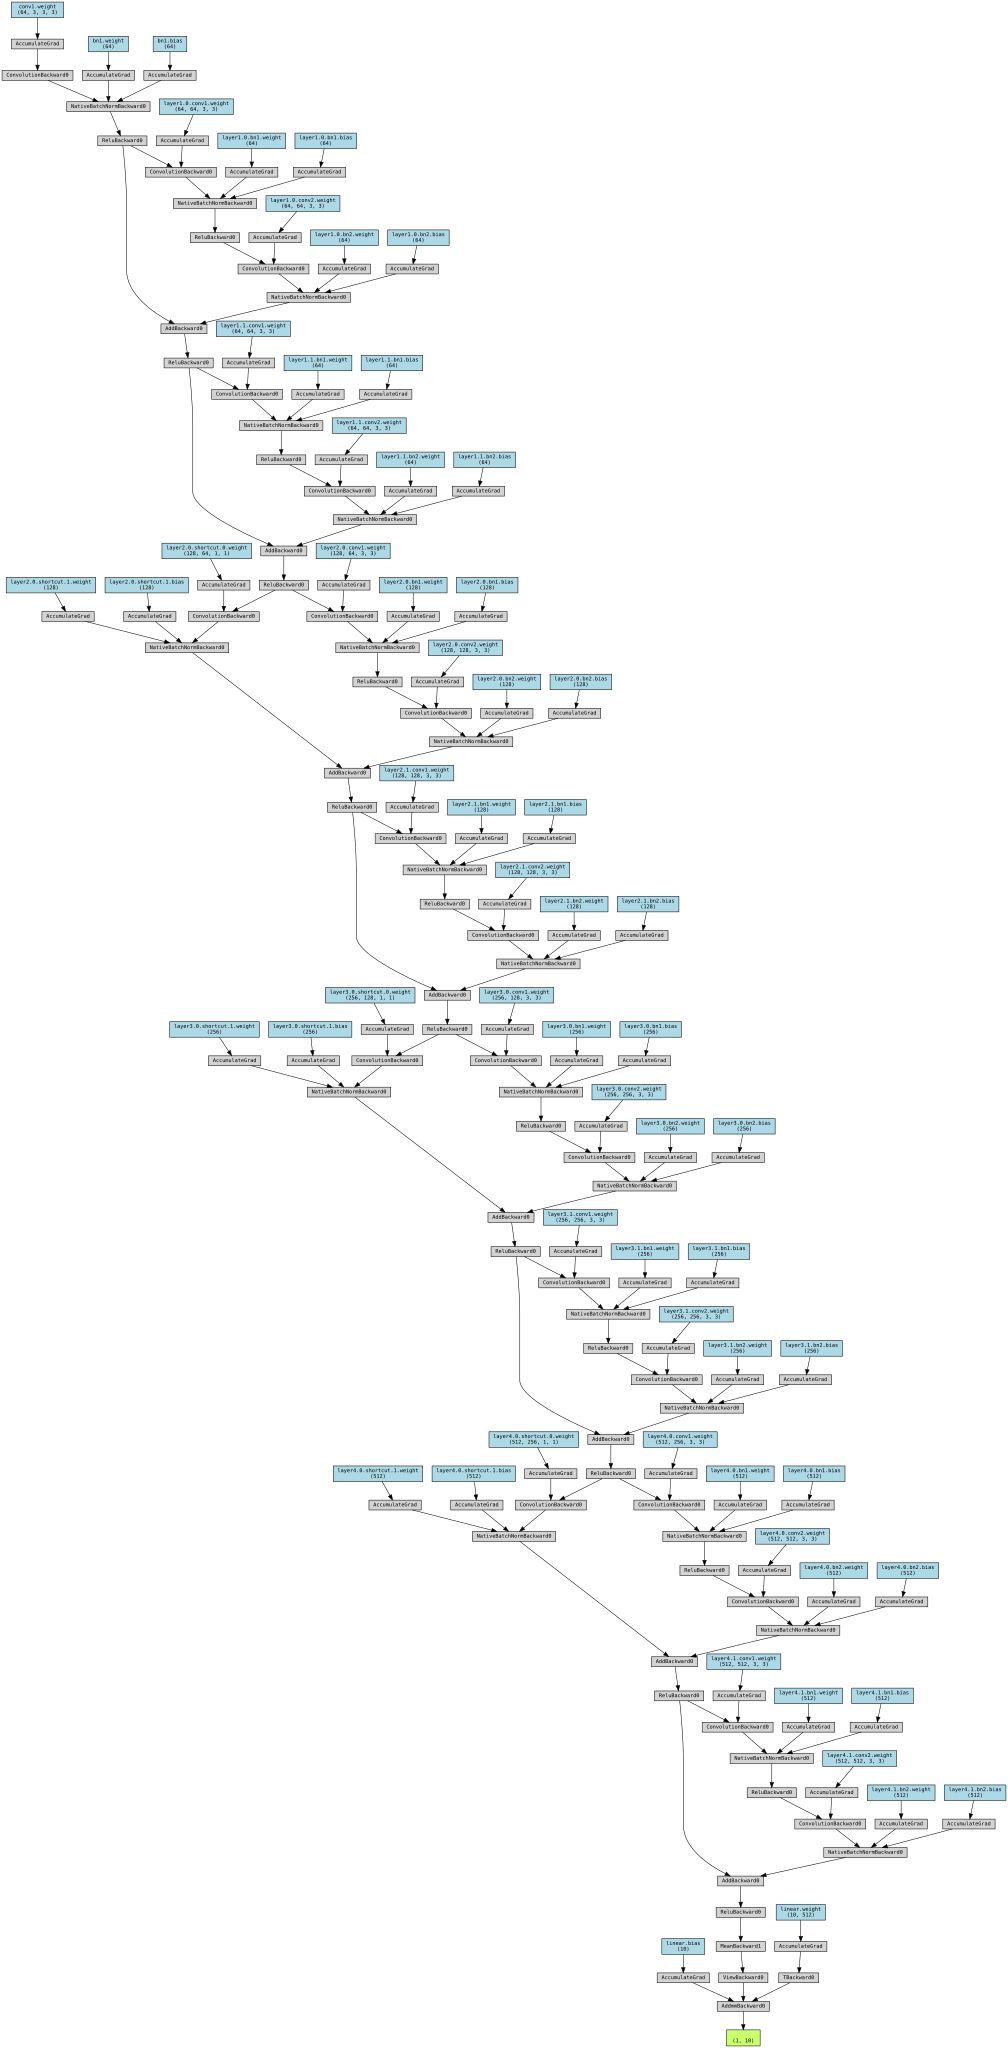

In [ ]:
from torchviz import make_dot

# Create a dummy input tensor
x = torch.randn(1, 3, 32, 32)

# Pass the input through the model
y = model(x)

# Create the graph visualization
dot = make_dot(y, params=dict(model.named_parameters()))

# Display the graph
dot

# 6. Summary

* **Why go deep?** To learn a rich hierarchy of features.
* **What's the problem?** The chain rule causes unstable (vanishing or exploding) gradients in very deep "plain" networks.
* **What are the solutions?**
    1.  **Activations:** Use **ReLU**. Its derivative is `1`, allowing gradients to flow.
    2.  **Normalization:** Use **Batch Norm**. It stabilizes the activations between layers.
    3.  **Architecture:** Use **Residual Connections** (ResNet). They provide a gradient "shortcut" or "superhighway" (`+ 1`) that prevents the gradient from ever vanishing.